In [20]:
import pandas as pd


In [21]:
matches=pd.read_csv("./datasets/dim_match_summary.csv")
matches.head()

FileNotFoundError: [Errno 2] No such file or directory: './datasets/dim_match_summary.csv'

In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   team1      206 non-null    object
 1   team2      206 non-null    object
 2   winner     206 non-null    object
 3   margin     206 non-null    object
 4   matchDate  206 non-null    object
 5   match_id   206 non-null    object
dtypes: object(6)
memory usage: 9.8+ KB


In [ ]:
matches.isnull().sum()

team1        0
team2        0
winner       0
margin       0
matchDate    0
match_id     0
dtype: int64

In [ ]:
matches.tail()

,team1,team2,winner,margin,matchDate,match_id
201,Mumbai,RCB,RCB,8 wickets,"Apr 2, 2023",T202485
202,Royals,Sunrisers,Royals,72 runs,"Apr 2, 2023",T209117
203,Super Giants,Capitals,Super Giants,50 runs,"Apr 1, 2023",T208512
204,Punjab Kings,KKR,Punjab Kings,7 runs,"Apr 1, 2023",T202853
205,Super Kings,Titans,Titans,5 wickets,"Mar 31, 2023",T201566


In [ ]:
matches.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
201    False
202    False
203    False
204    False
205    False
Length: 206, dtype: bool

Remember:The 'inplace = True' will make sure that

In [ ]:
matches.drop_duplicates(inplace=True)

In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   team1      206 non-null    object
 1   team2      206 non-null    object
 2   winner     206 non-null    object
 3   margin     206 non-null    object
 4   matchDate  206 non-null    object
 5   match_id   206 non-null    object
dtypes: object(6)
memory usage: 9.8+ KB


In [ ]:
#most successful team
top_teams = matches['winner'].value_counts().head()
top_teams

winner
Super Kings    25
RCB            25
Titans         23
Royals         22
KKR            21
Name: count, dtype: int64

In [ ]:
#close matches
close_matches = matches[(matches['margin'].str.contains('run'))&(matches['margin'].str.extract('(\d)').astype(int)<10)].any(axis=1)
close_matches


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\tamra\AppData\Local\Temp\ipykernel_26756\2590406690.py:2: SyntaxWarning: invalid escape sequence '\d'
  close_matches = matches[(matches['margin'].str.contains('run'))&(matches['margin'].str.extract('(\d)').astype(int)<10)].any(axis=1)


0      False
1      False
2      False
3      False
4      False
       ...  
201    False
202    False
203    False
204    False
205    False
Length: 206, dtype: bool

In [ ]:
batting= pd.read_csv("./datasets/fact_bating_summary.csv")
players=pd.read_csv("./datasets/dim_players.csv")

In [ ]:
batting.head()

,match_id,match,teamInnings,battingPos,batsmanName,out/not_out,runs,balls,4s,6s,SR
0,T203817,Super Kings Vs KKR,Super Kings,1,RuturajGaikwad,out,32,27,3,1,118.51
1,T203817,Super Kings Vs KKR,Super Kings,2,FafduPlessis,out,86,59,7,3,145.76
2,T203817,Super Kings Vs KKR,Super Kings,3,RobinUthappa,out,31,15,0,3,206.66
3,T203817,Super Kings Vs KKR,Super Kings,4,MoeenAli,not_out,37,20,2,3,185.00
4,T203817,Super Kings Vs KKR,KKR,1,ShubmanGill,out,51,43,6,0,118.60


In [ ]:
players.head()

,name,team,battingStyle,bowlingStyle,playingRole
0,RuturajGaikwad,Super Kings,Right hand Bat,Right arm Offbreak,Batter
1,FafduPlessis,Super Kings,Right hand Bat,Legbreak,Middle order Batter
2,RobinUthappa,Super Kings,Right hand Bat,Right arm Medium,Batter
3,MoeenAli,Super Kings,Left hand Bat,Right arm Offbreak,Batting Allrounder
4,ShubmanGill,KKR,Right hand Bat,Right arm Offbreak,Opening Batter


In [ ]:
#top runs scorers:
top_scorers=(batting.groupby('batsmanName')["runs"].sum().reset_index().sort_values(by='runs',ascending=False).head(10))
top_scorers

,batsmanName,runs
222,ShubmanGill,1851
66,FafduPlessis,1831
197,RuturajGaikwad,1593
97,KLRahul,1516
95,JosButtler,1509
216,ShikharDhawan,1392
251,ViratKohli,1385
204,SanjuSamson,1304
230,SuryakumarYadav,1225
69,GlennMaxwell,1214


In [ ]:
merged=top_scorers.merge(players,left_on='batsmanName',right_on='name')

In [ ]:
merged

,batsmanName,runs,name,team,battingStyle,bowlingStyle,playingRole
0,ShubmanGill,1851,ShubmanGill,KKR,Right hand Bat,Right arm Offbreak,Opening Batter
1,FafduPlessis,1831,FafduPlessis,Super Kings,Right hand Bat,Legbreak,Middle order Batter
2,RuturajGaikwad,1593,RuturajGaikwad,Super Kings,Right hand Bat,Right arm Offbreak,Batter
3,KLRahul,1516,KLRahul,Punjab Kings,Right hand Bat,Not Available,Wicketkeeper Batter
4,JosButtler,1509,JosButtler,Royals,Right hand Bat,Not Available,Wicketkeeper Batter
5,ShikharDhawan,1392,ShikharDhawan,Capitals,Left hand Bat,Right arm Offbreak,Opening Batter
6,ViratKohli,1385,ViratKohli,RCB,Right hand Bat,Right arm Medium,Top order Batter
7,SanjuSamson,1304,SanjuSamson,Royals,Right hand Bat,Not Available,Wicketkeeper Batter
8,SuryakumarYadav,1225,SuryakumarYadav,Mumbai,Right hand Bat,"Right arm Medium, Right arm Offbreak",Batter
9,GlennMaxwell,1214,GlennMaxwell,RCB,Right hand Bat,Right arm Offbreak,Batting Allrounder


In [ ]:
bowling=pd.read_csv("./datasets/fact_bowling_summary.csv")

In [ ]:
#top wicket takers
top_wickets=(bowling.groupby('bowlerName')["wickets"].sum().reset_index().sort_values(by='wickets',ascending=False).head(10))
top_wickets

,bowlerName,wickets
110,MohammedShami,67
201,YuzvendraChahal,66
54,HarshalPatel,65
141,RashidKhan,63
20,AveshKhan,47
19,ArshdeepSingh,45
75,KagisoRabada,45
189,VarunChakravarthy,44
163,ShardulThakur,43
181,TrentBoult,42


In [ ]:
#Best economy (with condition)
economy=(bowling.groupby)

In [ ]:
#1. Top 10 batsmen based on past 3 years total runs scored.

top10_batsmen = (batting.groupby('batsmanName')["runs"].sum()
                .reset_index()
                .sort_values(by='runs', ascending=False)
                .head(10))

top10_batsmen


NameError: name 'batting' is not defined

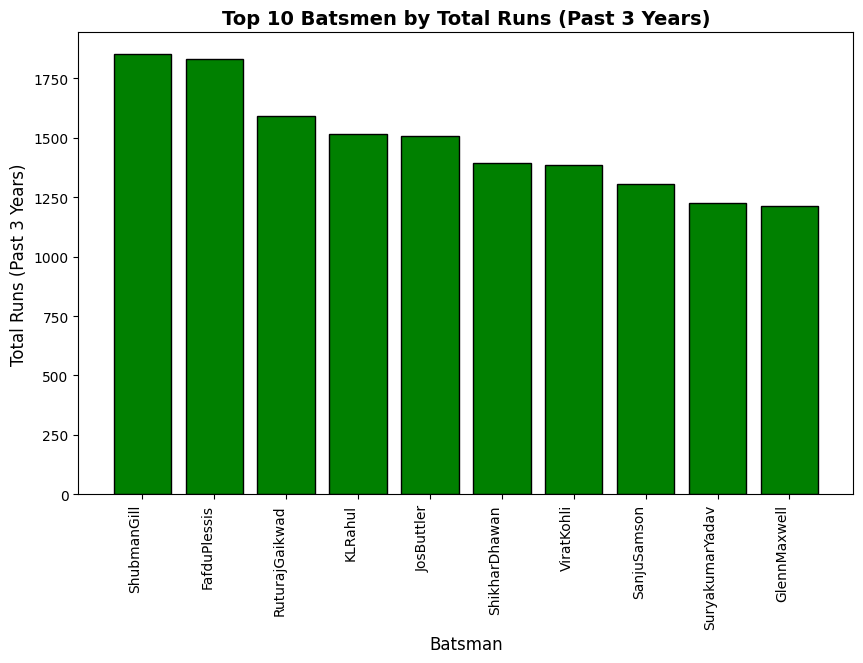

In [ ]:
#1.
import matplotlib.pyplot as plt

# Get Top 10 batsmen
top_batsmens = (batting.groupby('batsmanName')["runs"].sum()
                .reset_index()
                .sort_values(by='runs', ascending=False)
                .head(10))
plt.figure(figsize=(10,6))
plt.bar(top_batsmens['batsmanName'], top_batsmens['runs'], color='green', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("Batsman", fontsize=12)
plt.ylabel("Total Runs (Past 3 Years)", fontsize=12)
plt.title("Top 10 Batsmen by Total Runs (Past 3 Years)", fontsize=14, fontweight='bold')
plt.show()



In [22]:
#2. Top 10 batsmen based on past 3 years batting average. (min 60 balls faced in each 
#season) 
bat_agg = (batting.groupby("batsmanName")
                  .agg(runs=("runs","sum"),
                       balls=("balls","sum"),
                      ))
finishers = (bat_agg.query("balls >= 100")
                    .assign(batting_average=lambda x:  x["runs"] / x["balls"])
                    .sort_values("batting_average", ascending=False)
                    .head(10))
print(finishers[["runs","balls","batting_average"]])


NameError: name 'batting' is not defined

                 runs  balls  batting_average
batsmanName                                  
TimDavid          418    235         1.778723
HeinrichKlaasen   448    253         1.770751
RashidKhan        304    172         1.767442
LiamLivingstone   758    452         1.676991
PhilSalt          218    133         1.639098
GlennMaxwell     1214    752         1.614362
SuryakumarYadav  1225    763         1.605505
CameronGreen      452    282         1.602837
JiteshSharma      543    341         1.592375
AndreRussell      745    468         1.591880


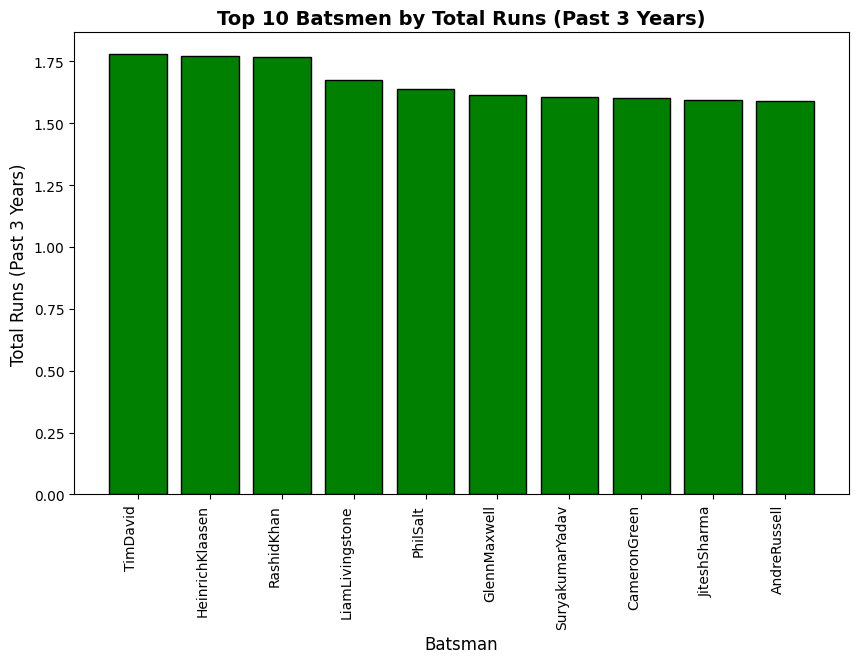

In [ ]:
#2.
print(finishers[["runs","balls","batting_average"]]) 
plt.figure(figsize=(10,6))
plt.bar(finishers.index,finishers['batting_average'], color='green', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("Batsman", fontsize=12)
plt.ylabel("Total Runs (Past 3 Years)", fontsize=12)
plt.title("Top 10 Batsmen by Total Runs (Past 3 Years)", fontsize=14, fontweight='bold')
plt.show()


In [ ]:
#3.. Top 10 batsmen based on past 3 years strike rate (min 60 balls faced in each 
#season)
bat_agg = (batting.groupby("batsmanName")
                  .agg(runs=("runs","sum"),
                       balls=("balls","sum"),
                      ))
finishers = (bat_agg.query("balls >= 100")
                    .assign(strike_rate=lambda x: 60 * x["runs"] / x["balls"])
                    .sort_values("strike_rate", ascending=False)
                    .head(10))
print(finishers[["runs","balls","strike_rate"]]) 

                 runs  balls  strike_rate
batsmanName                              
TimDavid          418    235   106.723404
HeinrichKlaasen   448    253   106.245059
RashidKhan        304    172   106.046512
LiamLivingstone   758    452   100.619469
PhilSalt          218    133    98.345865
GlennMaxwell     1214    752    96.861702
SuryakumarYadav  1225    763    96.330275
CameronGreen      452    282    96.170213
JiteshSharma      543    341    95.542522
AndreRussell      745    468    95.512821


                 runs  balls  strike_rate
batsmanName                              
TimDavid          418    235   106.723404
HeinrichKlaasen   448    253   106.245059
RashidKhan        304    172   106.046512
LiamLivingstone   758    452   100.619469
PhilSalt          218    133    98.345865
GlennMaxwell     1214    752    96.861702
SuryakumarYadav  1225    763    96.330275
CameronGreen      452    282    96.170213
JiteshSharma      543    341    95.542522
AndreRussell      745    468    95.512821


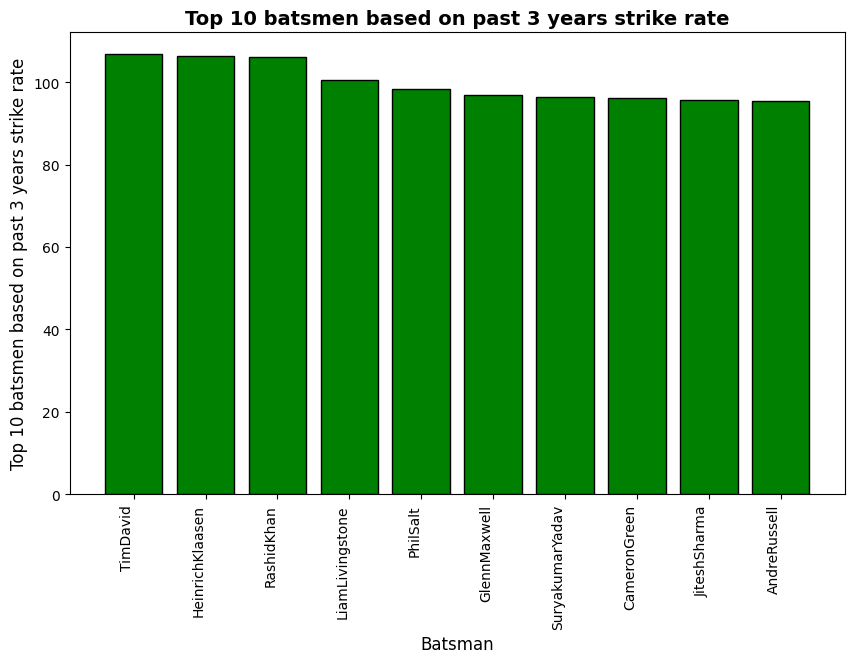

In [ ]:
#3.
# Recalculate finishers for strike rate
finishers = (
	bat_agg.query("balls >= 100")
		   .assign(strike_rate=lambda x: 60 * x["runs"] / x["balls"])
		   .sort_values("strike_rate", ascending=False)
		   .head(10)
)
print(finishers[["runs", "balls", "strike_rate"]])
plt.figure(figsize=(10,6))
plt.bar(finishers.index, finishers['strike_rate'], color='green', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("Batsman", fontsize=12)
plt.ylabel("Top 10 batsmen based on past 3 years strike rate", fontsize=12)
plt.title("Top 10 batsmen based on past 3 years strike rate", fontsize=14, fontweight='bold')
plt.show()


In [ ]:
#4. Top 10 bowlers based on past 3 years total wickets taken. 
import pandas as pd
matches = pd.read_csv("./Datasets/fact_bowling_summary.csv")
top10_bowler = (matches.groupby('bowlerName')["wickets"].sum()
                .reset_index()
                .sort_values(by='wickets', ascending=False)
                .head(10))

top10_bowler


,bowlerName,wickets
110,MohammedShami,67
201,YuzvendraChahal,66
54,HarshalPatel,65
141,RashidKhan,63
20,AveshKhan,47
19,ArshdeepSingh,45
75,KagisoRabada,45
189,VarunChakravarthy,44
163,ShardulThakur,43
181,TrentBoult,42


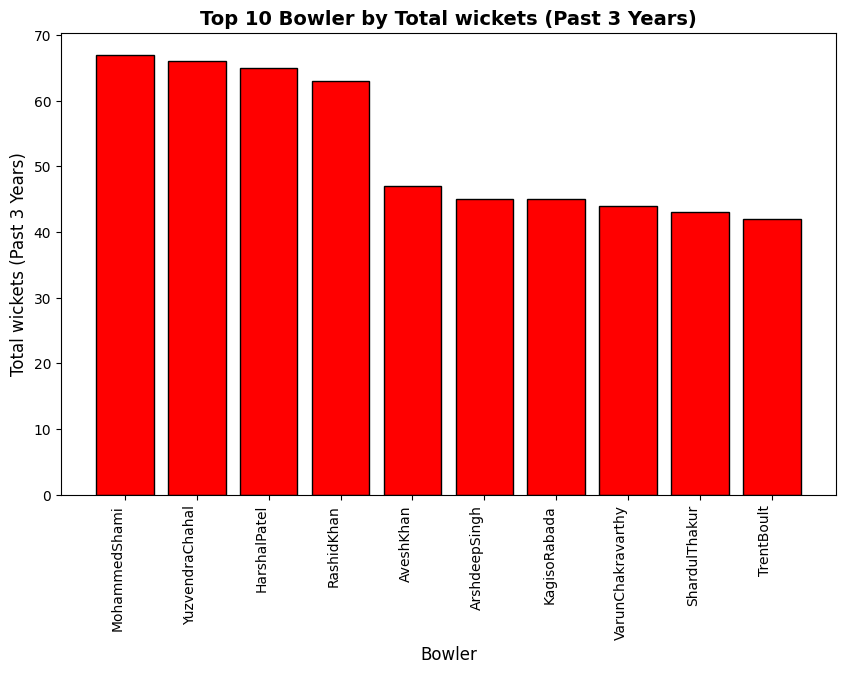

In [ ]:
#4.
import matplotlib.pyplot as plt
matches = pd.read_csv("./Datasets/fact_bowling_summary.csv")
top10_bowler = (matches.groupby('bowlerName')["wickets"].sum()
                .reset_index()
                .sort_values(by='wickets', ascending=False)
                .head(10))

top10_bowler
plt.figure(figsize=(10,6))
plt.bar(top10_bowler['bowlerName'], top10_bowler['wickets'], color='red', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("Bowler", fontsize=12)
plt.ylabel("Total wickets (Past 3 Years)", fontsize=12)
plt.title("Top 10 Bowler by Total wickets (Past 3 Years)", fontsize=14, fontweight='bold')
plt.show()


In [ ]:
#5. Top 10 bowlers based on past 3 years bowling average. (min 60 balls bowled in each 
#season).
import pandas as pd
matches = pd.read_csv("./Datasets/fact_bowling_summary.csv")
bowl_agg = (bowling.groupby("bowlerName")
                  .agg(runs=("runs","sum"),
                       overs=("overs","sum"),
                       wickets=("wickets","sum"),
                      ))
finishers = (bowl_agg.query("overs >= 10")
                    .assign(bowler_average=lambda x:  x["runs"] / x["overs"])
                    .sort_values("bowler_average", ascending=False)
                    .head(10))
print(finishers[["runs","overs","wickets","bowler_average"]]) 

                  runs  overs  wickets  bowler_average
bowlerName                                            
ArshadKhan         190   13.7        5       13.868613
RiyanParag         132   10.1        2       13.069307
NavdeepSaini       198   16.0        6       12.375000
OdeanSmith         178   15.0        6       11.866667
ShreyasGopal       118   10.0        1       11.800000
AkashDeep          264   23.5        6       11.234043
TymalMills         190   17.0        6       11.176471
KartikTyagi        295   27.7        6       10.649819
JhyeRichardson     117   11.0        3       10.636364
VijaykumarVyshak   253   24.0        9       10.541667


                  runs  overs  wickets  bowler_average
bowlerName                                            
ArshadKhan         190   13.7        5       13.868613
RiyanParag         132   10.1        2       13.069307
NavdeepSaini       198   16.0        6       12.375000
OdeanSmith         178   15.0        6       11.866667
ShreyasGopal       118   10.0        1       11.800000
AkashDeep          264   23.5        6       11.234043
TymalMills         190   17.0        6       11.176471
KartikTyagi        295   27.7        6       10.649819
JhyeRichardson     117   11.0        3       10.636364
VijaykumarVyshak   253   24.0        9       10.541667


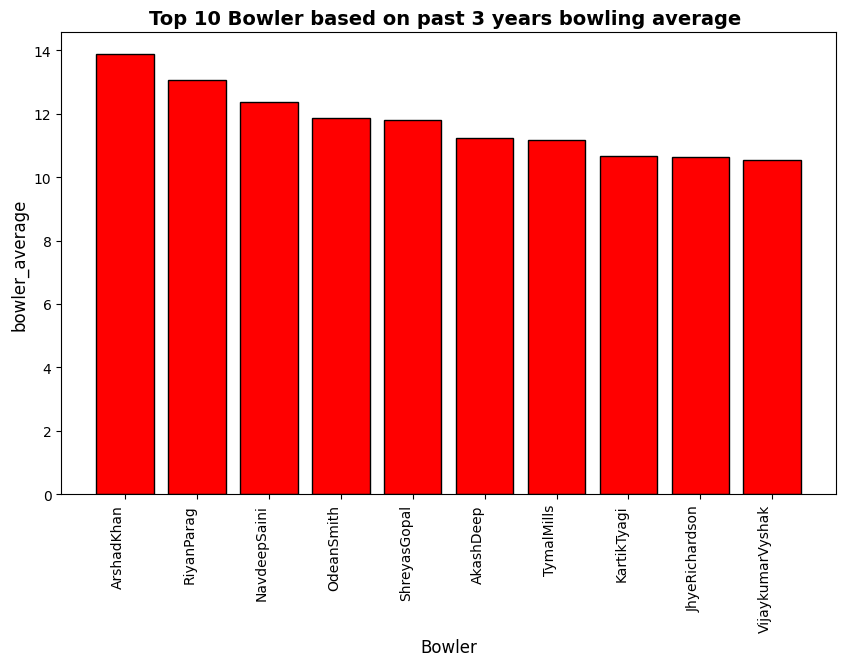

In [ ]:
#5.
print(finishers[["runs","overs","wickets","bowler_average"]]) 
plt.figure(figsize=(10,6))
plt.bar(finishers.index, finishers['bowler_average'], color='red', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("Bowler", fontsize=12)
plt.ylabel("bowler_average", fontsize=12)
plt.title("Top 10 Bowler based on past 3 years bowling average ", fontsize=14, fontweight='bold')
plt.show()

In [ ]:
#6. Top 10 bowlers based on past 3 years economy rate. (min 60 balls bowled in each 
#season).

economy = (bowling.groupby('bowlerName')
            .agg({'overs': "sum", 'runs': 'sum'})
            .query('overs > 10')
            .assign(economy=lambda x: x['runs'] / x['overs'])
            .sort_values(by='economy')
            .reset_index()
            .head(10)
            )

economy

,bowlerName,overs,runs,economy
0,SunilNarine,160.0,1056,6.600000
1,MitchellSantner,31.0,211,6.806452
2,DavidWilley,26.0,177,6.807692
3,MohsinKhan,43.0,304,7.069767
4,MoeenAli,70.7,501,7.086280
5,AxarPatel,132.0,939,7.113636
6,ShakibAlHasan,26.0,187,7.192308
7,RashidKhan,182.5,1317,7.216438
8,JaspritBumrah,108.2,793,7.329020
9,JayantYadav,21.0,156,7.428571


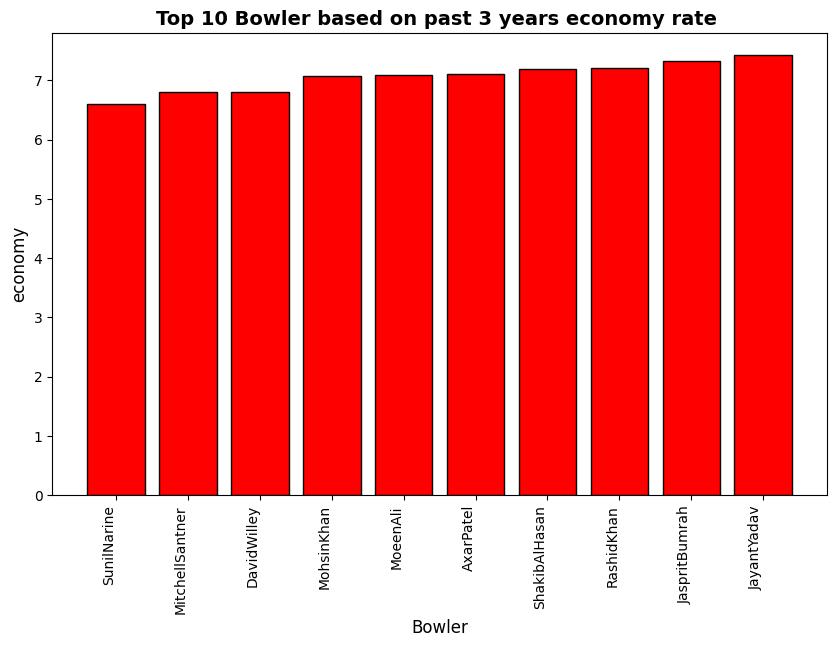

In [ ]:
#6.
import matplotlib.pyplot as plt
economy = (bowling.groupby('bowlerName')
            .agg({'overs': "sum", 'runs': 'sum'})
            .query('overs > 10')
            .assign(economy=lambda x: x['runs'] / x['overs'])
            .sort_values(by='economy')
            .head(10)
            )

economy
plt.figure(figsize=(10,6))
plt.bar(economy.index, economy['economy'], color='red', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("Bowler", fontsize=12)
plt.ylabel("economy", fontsize=12)
plt.title("Top 10 Bowler based on past 3 years economy rate ", fontsize=14, fontweight='bold')
plt.show()



In [ ]:
#7. Top 5 batsmen based on past 3 years boundary % (fours and sixes). 
top5_batsmen = (batting.groupby('batsmanName')
                .agg({'4s': 'sum', '6s': 'sum', 'balls': 'sum'})
                .query('balls > 100')
                .assign(boundary_percentage=lambda x: (x['4s'] + x['6s']) / x['balls'] * 100)
                .sort_values(by='boundary_percentage', ascending=False)
                .head(5)
                )
print(top5_batsmen)

                  4s  6s  balls  boundary_percentage
batsmanName                                         
RashidKhan        20  24    172            25.581395
PhilSalt          24  10    133            25.563910
YashasviJaiswal  142  46    744            25.268817
PrithviShaw      102  28    532            24.436090
EvinLewis         26  10    149            24.161074


                  4s  6s  balls  boundary_percentage
batsmanName                                         
RashidKhan        20  24    172            25.581395
PhilSalt          24  10    133            25.563910
YashasviJaiswal  142  46    744            25.268817
PrithviShaw      102  28    532            24.436090
EvinLewis         26  10    149            24.161074


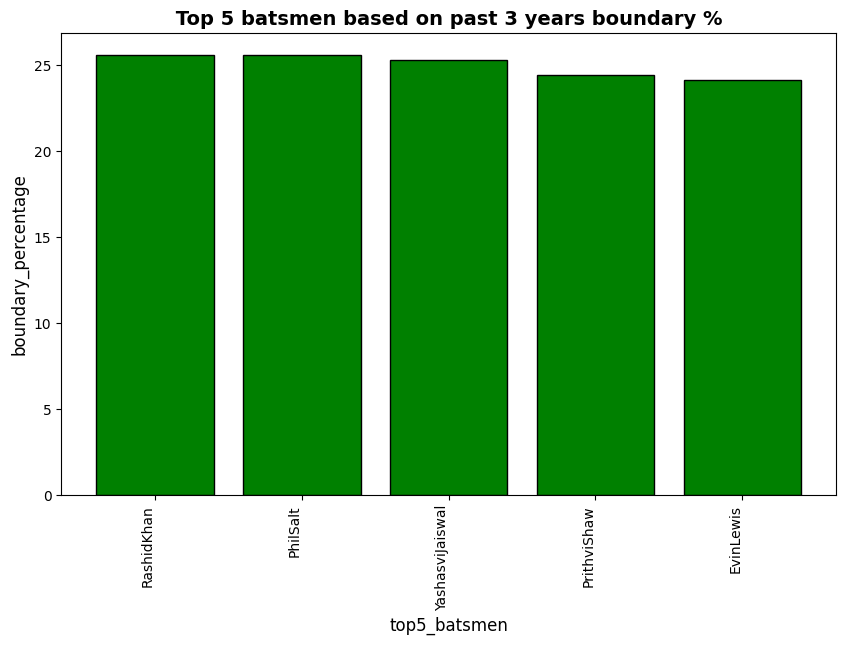

In [ ]:
#7.
import matplotlib.pyplot as plt
top5_batsmen = (batting.groupby('batsmanName')
                .agg({'4s': 'sum', '6s': 'sum', 'balls': 'sum'})
                .query('balls > 100')
                .assign(boundary_percentage=lambda x: (x['4s'] + x['6s']) / x['balls'] * 100)
                .sort_values(by='boundary_percentage', ascending=False)
                .head(5)
                )
print(top5_batsmen)
plt.figure(figsize=(10,6))
plt.bar(top5_batsmen.index, top5_batsmen['boundary_percentage'], color='green', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("top5_batsmen", fontsize=12)
plt.ylabel("boundary_percentage", fontsize=12)
plt.title(" Top 5 batsmen based on past 3 years boundary % ", fontsize=14, fontweight='bold')
plt.show()



In [ ]:
#8. Top 5 bowlers based on past 3 years dot ball %.
import pandas as pd
matches = pd.read_csv("./Datasets/fact_bowling_summary.csv") 
bowling = bowling.copy()
bowling["balls"] = bowling["overs"] * 6
dot_ball_stats = (
    bowling.groupby("bowlerName")
           .agg(dot_balls=("0s", "sum"), balls=("balls", "sum"))
           .assign(dot_ball_percent=lambda x: 100 * x["dot_balls"] / x["balls"])
           .query("balls > 0")
           .sort_values("dot_ball_percent", ascending=False)
           .head(5)
)
print(dot_ball_stats[["dot_balls","balls","dot_ball_percent"]])

                dot_balls  balls  dot_ball_percent
bowlerName                                        
ShreyasIyer             4    6.0         66.666667
ImranTahir             14   24.0         58.333333
ReeceTopley             7   12.0         58.333333
DewaldBrevis            1    1.8         55.555556
SimarjeetSingh         57  108.0         52.777778


                dot_balls  balls  dot_ball_percent
bowlerName                                        
ShreyasIyer             4    6.0         66.666667
ImranTahir             14   24.0         58.333333
ReeceTopley             7   12.0         58.333333
DewaldBrevis            1    1.8         55.555556
SimarjeetSingh         57  108.0         52.777778


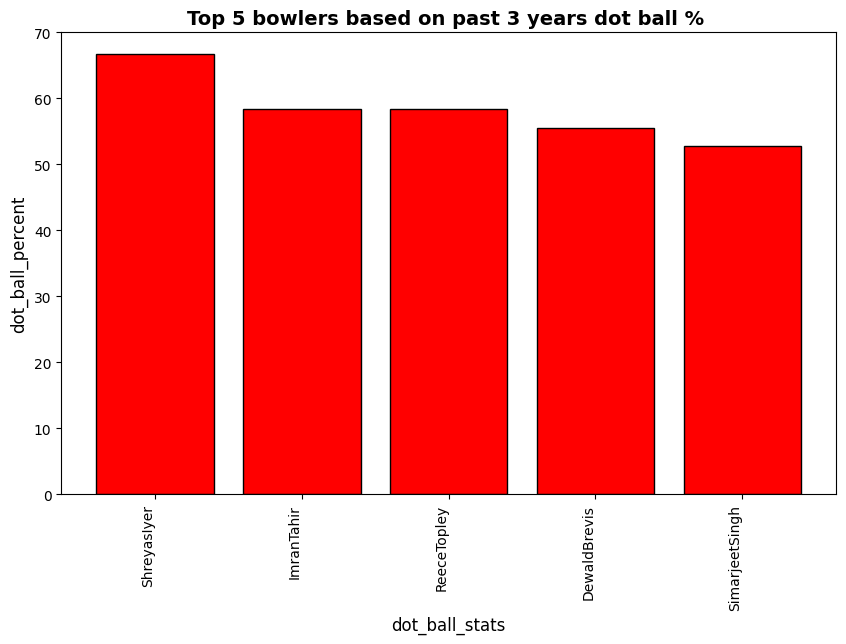

In [ ]:
#8.
print(dot_ball_stats[["dot_balls","balls","dot_ball_percent"]])
plt.figure(figsize=(10,6))
plt.bar(dot_ball_stats.index, dot_ball_stats['dot_ball_percent'], color='red', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("dot_ball_stats", fontsize=12)
plt.ylabel("dot_ball_percent", fontsize=12)
plt.title("Top 5 bowlers based on past 3 years dot ball % ", fontsize=14, fontweight='bold')
plt.show()

In [ ]:
#9.Top 4 teams based on past 3 years winning %.  
import pandas as pd
matches=pd.read_csv("./Datasets/dim_match_summary.csv")
played_t1=matches["team1"].value_counts().sort_index()
played_t2=matches["team2"].value_counts().sort_index()

tot_played=played_t1+played_t2

wins=matches["winner"].value_counts().sort_index()

top_teams=(wins/tot_played)*100
top_teams.head(4)

winner
Capitals        48.837209
KKR             46.666667
Mumbai          45.454545
Punjab Kings    45.238095
Name: count, dtype: float64

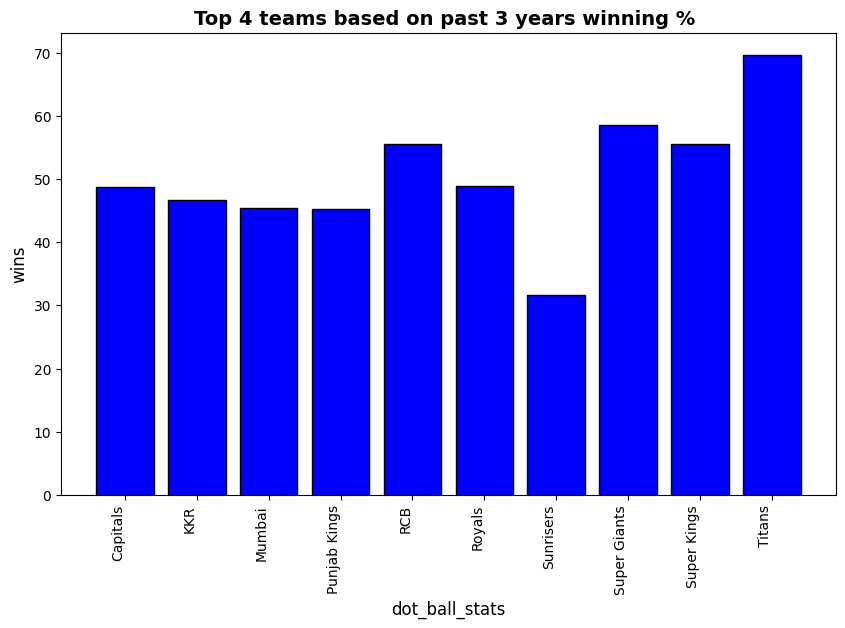

In [ ]:
#9.
import matplotlib.pyplot as plt
matches=pd.read_csv("./Datasets/dim_match_summary.csv")
played_t1=matches["team1"].value_counts().sort_index()
played_t2=matches["team2"].value_counts().sort_index()

tot_played=played_t1+played_t2

wins=matches["winner"].value_counts().sort_index()

top_teams=(wins/tot_played)*100
top_teams.head(4)
plt.figure(figsize=(10,6))
plt.bar(top_teams.index, top_teams, color='blue', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("dot_ball_stats", fontsize=12)
plt.ylabel("wins", fontsize=12)
plt.title("Top 4 teams based on past 3 years winning % ", fontsize=14, fontweight='bold')
plt.show()


In [ ]:
#10.Top 2 teams with the highest number of wins achieved by chasing targets over the 
#past 3 years.
 
matches['year'] = pd.to_datetime(matches['matchDate'], errors='coerce').dt.year
chasing_wins = matches[matches['margin'].str.contains("wickets", case=False, na=False)]
chasing_counts = chasing_wins['winner'].value_counts()
top2_chasing = chasing_counts.head(2)
print(top2_chasing)

winner
KKR         14
Capitals    14
Name: count, dtype: int64


winner
KKR         14
Capitals    14
Name: count, dtype: int64


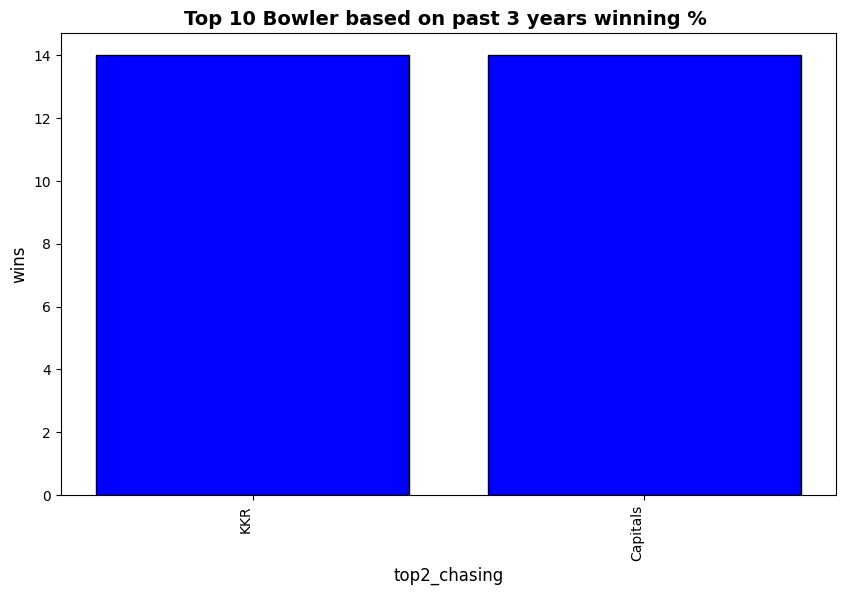

In [ ]:
#10.
print(top2_chasing)
plt.figure(figsize=(10,6))
plt.bar(top2_chasing.index, top2_chasing, color='blue', edgecolor='black')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.xlabel("top2_chasing", fontsize=12)
plt.ylabel("wins", fontsize=12)
plt.title("Top 10 Bowler based on past 3 years winning % ", fontsize=14, fontweight='bold')
plt.show()
